# 02 - Image features with a small pretrained CNN

I do not have a GPU, so fine-tuning a big vision model is out. The plan: take a pretrained
**MobileNetV3-small** (about 10 MB of weights), cut off the classifier and use the 576-number vector it produces
for every image as a fixed feature. No training happens here, just one forward pass per image, which is fine on a CPU.

Images are read straight from the zip from notebook 01 and features are cached in `data/image_features.npz`,
so this notebook only needs to run once.

In [1]:
import io
import os
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA

import torch
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "dataset.csv")
zf = zipfile.ZipFile(DATA_DIR / "data.zip")
print(df.shape)

(487, 6)


In [2]:
torch.set_num_threads(max(1, (os.cpu_count() or 2) - 1))

weights = MobileNet_V3_Small_Weights.DEFAULT   # downloads ~10 MB the first time
net = mobilenet_v3_small(weights=weights)
net.classifier = torch.nn.Identity()           # keep the pooled features, drop the 1000-class head
net.eval()
prep = weights.transforms()                    # resize 256 -> center crop 224 -> imagenet normalisation

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\user/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth


100.0%


Batches of 32. If an image cannot be opened it is skipped and dropped from the feature file, so a broken file does not stop the run.

In [3]:
def load_image(name):
    return Image.open(io.BytesIO(zf.read(name))).convert("RGB")


BATCH = 32
all_ids, all_feats, broken = [], [], []
start_time = time.time()

for start in range(0, len(df), BATCH):
    chunk = df.iloc[start:start + BATCH]
    ids, tensors = [], []
    for pid, name in zip(chunk["id"], chunk["img_name"]):
        try:
            tensors.append(prep(load_image(name)))
            ids.append(pid)
        except Exception:
            broken.append(pid)

    if tensors:
        with torch.no_grad():
            out = net(torch.stack(tensors)).numpy()
        all_ids.extend(ids)
        all_feats.append(out)

    done = min(start + BATCH, len(df))
    if (start // BATCH) % 10 == 0 or done == len(df):
        print(f"{done}/{len(df)} images, {time.time() - start_time:.0f}s")

feats = np.vstack(all_feats).astype("float32")
ids = np.array(all_ids)
print(feats.shape, "| broken images:", len(broken))

32/487 images, 2s
352/487 images, 12s
487/487 images, 17s
(487, 576) | broken images: 0


In [4]:
np.savez_compressed(DATA_DIR / "image_features.npz", ids=ids, feats=feats)
print("saved,", round((DATA_DIR / "image_features.npz").stat().st_size / 1e6, 1), "MB")

saved, 1.0 MB


## Do these features carry any sentiment signal?

Quick check: squash the vectors to 2D with PCA and colour by class. I do not expect clean clusters
(a CNN trained on ImageNet knows about dogs and cars, not about mood), but it is a useful sanity check that the
features are not garbage.

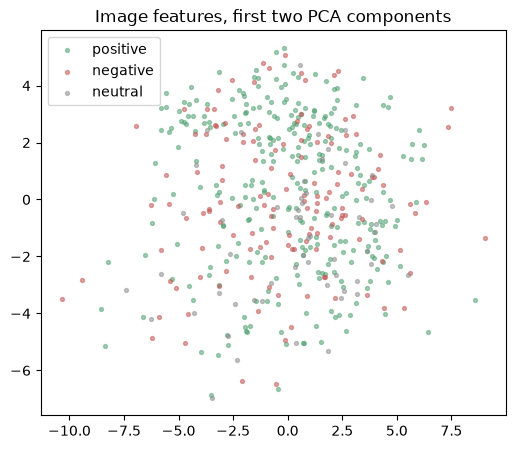

In [5]:
lab = df.set_index("id").loc[ids, "label"].values
xy = PCA(n_components=2, random_state=42).fit_transform(feats)

colors = {"positive": "#4c9f70", "negative": "#c0504d", "neutral": "#8a8a8a"}
plt.figure(figsize=(6, 5))
for name, c in colors.items():
    m = lab == name
    plt.scatter(xy[m, 0], xy[m, 1], s=8, alpha=0.5, c=c, label=name)
plt.legend()
plt.title("Image features, first two PCA components")
plt.show()

Next: `03_text_features_and_fusion.ipynb`, where the text side is built and the two are combined.